In [1]:
import matplotlib.pyplot as plt
import numpy as np
from OSSWEM import SSWEM

In [2]:
# Check every function returns without error
M = SSWEM(32,
          10., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          2.e-11, # df/dy [m-1 s-1]
          1.e-3, # Drag rate [m-1 s-1]
          1.e-1, # Viscosity [m s-2]
          h_relax=0.1 # Forcing rate for eta [s-1]
          )
M.resting_state()
M.flat_topog()
M.bowl_topog()
M.zero_forcing()
M.gyre_forcing()
M.channel_forcing()
M.set_eta_forcing(0.1)
M.perturb_eta(0.01, 10., 500.e3)
M.step(50.)
# _,_,_,_ = M.run(10., 10, 2)
u,v,h,t = M.run( 10., 1, 10)

Grid: dx = 31250.0 [m]
cg = 100.0 [m s-1]
Ld = 1000000.0 [m]
Scales: Ls=epsilon/D/beta = 50000.0 [m]
Scales: Lx/Ld = 1.0
Res: Ld/dx = 32.0
Res: Ls/dx = 1.6
CFL: dt*epsilon/D = 1e-05
CFL: dt*f = 0.00119375
CFL: dt*cg/dx = 0.032
CFL: dt*nu/dx^2 = 1.024e-09
CFL: dt*h_relax = 1.0
nsteps = 10
Time: Trun * fo = 0.01
Time: Trun * ( cg / L ) = 0.01
Running...
...done


Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.05
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 1000
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.5
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 2.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 25
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


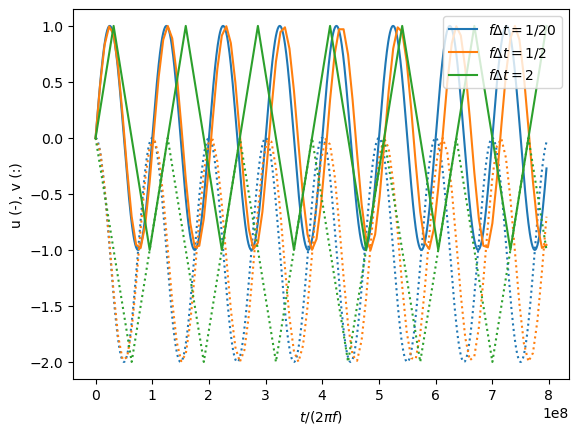

In [3]:
# Check pure intertial oscillations are stable and convergent
M = SSWEM(1,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.gyre_forcing()
u1, v1, _, time1 = M.run(500., 1, 1000)
M.resting_state()
u2, v2, _, time2 = M.run(5000., 1, 100)
M.resting_state()
u3, v3, _, time3 = M.run(20000., 1, 25)
plt.plot( time1 / ( 2 * np.pi * M.fo ), u1[:,0,0], label=r'$f \Delta t=1/20$' );
plt.plot( time1 / ( 2 * np.pi * M.fo ), v1[:,0,0], ':C0' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), u2[:,0,0], label=r'$f \Delta t=1/2$' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), v2[:,0,0], ':C1' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), u3[:,0,0], label=r'$f \Delta t=2$' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), v3[:,0,0], ':C2' );
plt.xlabel(r"$t / ( 2 \pi f )$");
plt.ylabel("u (-), v (:)")
plt.legend();

Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
CFL: dt*epsilon/D = 0.05
CFL: dt*f = 0.05
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 1000
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.5
CFL: dt*f = 0.5
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 2.0
CFL: dt*f = 2.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 25
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


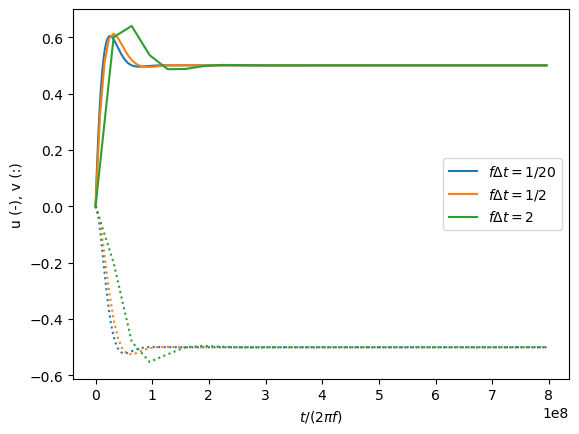

In [4]:
# Check pure damped intertial oscillations are stable and convergent
M = SSWEM(1,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          1.e-1, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.gyre_forcing()
u1, v1, _, time1 = M.run(500., 1, 1000)
M.resting_state()
u2, v2, _, time2 = M.run(5000., 1, 100)
M.resting_state()
u3, v3, _, time3 = M.run(20000., 1, 25)
plt.plot( time1 / ( 2 * np.pi * M.fo ), u1[:,0,0], label=r'$f \Delta t=1/20$' );
plt.plot( time1 / ( 2 * np.pi * M.fo ), v1[:,0,0], ':C0' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), u2[:,0,0], label=r'$f \Delta t=1/2$' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), v2[:,0,0], ':C1' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), u3[:,0,0], label=r'$f \Delta t=2$' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), v3[:,0,0], ':C2' );
plt.xlabel(r"$t / ( 2 \pi f )$");
plt.ylabel("u (-), v (:)")
plt.legend();

Grid: dx = 10.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


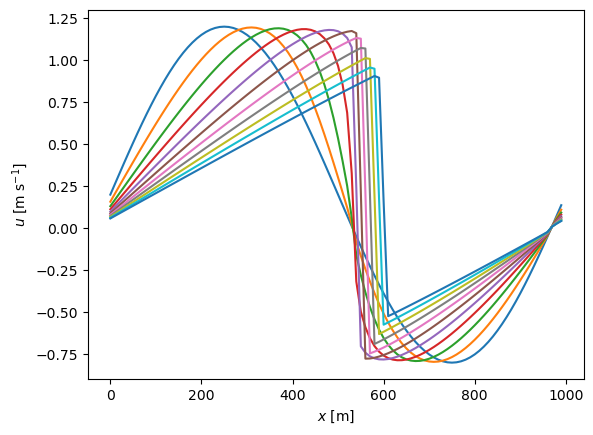

In [5]:
# Check the Burger term
M = SSWEM(100,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000., # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.u[0] = np.sin( 2 * np.pi * M.xu / M.Lx  ) + 0.2
u, v, _, time = M.run(5., 10, 10)
plt.plot(M.xq1, u[:,0,:].T);
plt.xlabel(r"$x$ [m]");
plt.ylabel("$u$ [m s$^{-1}$]");

Grid: dx = 100.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.1
nsteps = 2
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


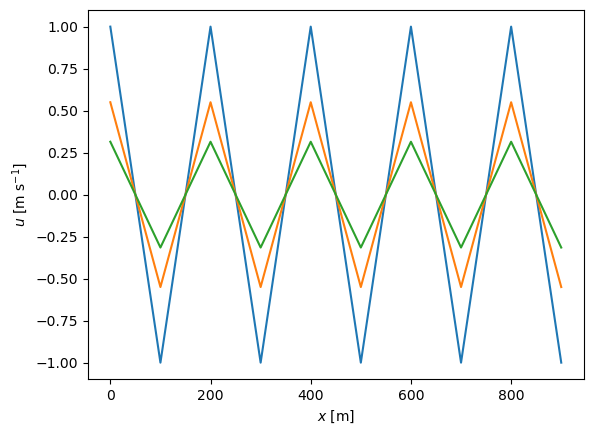

In [6]:
# Check the viscosity term
M = SSWEM(10,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000., # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          2e2 # Viscosity [m s-2]
          )
M.u[0] = np.cos( np.pi * M.xu / M.dx  )
u, v, _, time = M.run(5., 1, 2)
plt.plot(M.xq1, u[:,0,:].T);
plt.xlabel(r"$x$ [m]");
plt.ylabel("$u$ [m s$^{-1}$]");

Grid: dx = 12500.0 [m]
cg = 50.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.8
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.5
Running...
...done


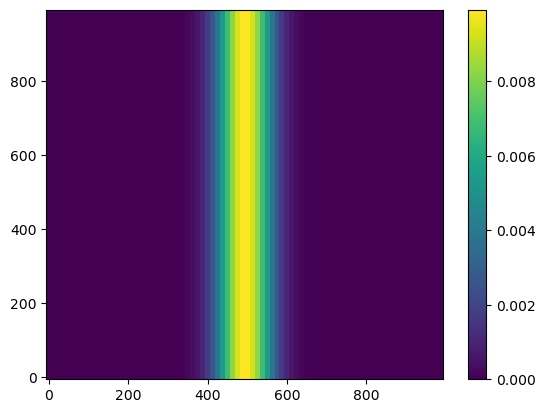

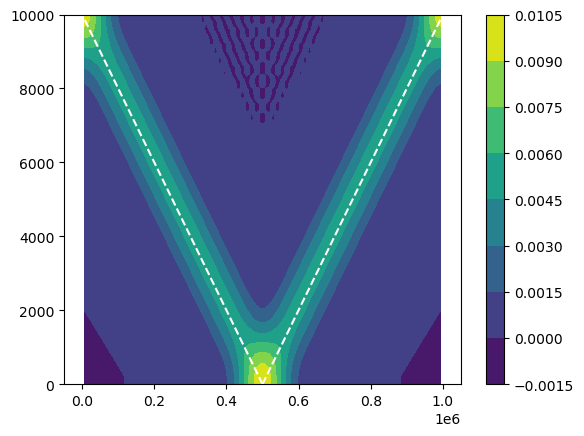

In [7]:
# Check gravity wave propagation
M = SSWEM(80,
          10., # Gravity [m s-2]
          250., # Max depth [m]
          1000.e3, # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0e3 # Viscosity [m s-2]
          )
M.perturb_eta(0.01, 50.e3, 500e3) 
plt.pcolormesh( M.xq/1e3, M.yq/1e3, M.eta() ); plt.colorbar();

u,v,h,time = M.run(200.,1,50);
plt.figure();
plt.contourf( M.xh1, time, M.eta(h)[:,0,:] ); plt.colorbar();
plt.plot( 500e3 + M.cg * time, time, '--w' );
plt.plot( 500e3 - M.cg * time, time, '--w' );